In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Instalamos imbalanced-learn
!pip install imbalanced-learn -q
from imblearn.over_sampling import SMOTE

# Importar TensorFlow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("=== DEEP LEARNING: CNN 1D ===")

# 1. Cargar el dataset optimizado
df = pd.read_csv("dataset_bci_optimizado.csv")

# 2. Re-definir el mapeo de clases y separar X e y
mapeo_clases = {'Reposo': 0, 'Imag_Izquierda': 1, 'Imag_Derecha': 2, 'Mov_Izquierda': 3, 'Mov_Derecha': 4}
X_np = df.drop(columns=['Condicion']).values
y_np = df['Condicion'].map(mapeo_clases).values

# 3. Configurar Validación Cruzada (k=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

test_accuracies, test_f1_macros, test_precisions, test_recalls = [], [], [], []
fold = 1

for train_idx, val_idx in cv.split(X_np, y_np):
    print(f"--- Entrenando Fold {fold}/5 ---")

    X_train, X_val = X_np[train_idx], X_np[val_idx]
    y_train, y_val = y_np[train_idx], y_np[val_idx]

    # Normalización correcta por Fold
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # SMOTE correcto por Fold
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Reshape 3D para la CNN 1D -> (muestras, 15 características, 1 canal)
    X_train_res = np.expand_dims(X_train_res, axis=-1)
    X_val_cnn = np.expand_dims(X_val, axis=-1)

    # 4. Arquitectura de la CNN 1D
    model = Sequential([
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(15, 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(filters=64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Flatten(),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(5, activation='softmax') # 5 clases de salida
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0)

    # Entrenamiento optimizado en la nube
    model.fit(
        X_train_res, y_train_res,
        epochs=50,
        batch_size=128,
        validation_data=(X_val_cnn, y_val),
        callbacks=[early_stopping],
        verbose=0
    )

    # Predicciones
    y_pred_probs = model.predict(X_val_cnn, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    test_accuracies.append(accuracy_score(y_val, y_pred))
    test_f1_macros.append(f1_score(y_val, y_pred, average='macro'))
    test_precisions.append(precision_score(y_val, y_pred, average='macro', zero_division=0))
    test_recalls.append(recall_score(y_val, y_pred, average='macro'))

    print(f"Fold {fold} Terminado -> Accuracy: {test_accuracies[-1]:.4f} | F1-Macro: {test_f1_macros[-1]:.4f}")
    fold += 1

print("\n--- RESULTADOS FINALES DE LA CNN 1D EN COLAB ---")
print(f"Accuracy Promedio:  {np.mean(test_accuracies):.6f}")
print(f"F1_Macro Promedio:  {np.mean(test_f1_macros):.6f}")
print(f"Precision Promedio: {np.mean(test_precisions):.6f}")
print(f"Recall Promedio:    {np.mean(test_recalls):.6f}")

=== DEEP LEARNING EN COLAB: CNN 1D ===
--- Entrenando Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Terminado -> Accuracy: 0.3187 | F1-Macro: 0.2599
--- Entrenando Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Terminado -> Accuracy: 0.2918 | F1-Macro: 0.2454
--- Entrenando Fold 3/5 ---


...

Fold 3 Terminado -> Accuracy: 0.3178 | F1-Macro: 0.2731
--- Entrenando Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Terminado -> Accuracy: 0.3236 | F1-Macro: 0.2658
--- Entrenando Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Terminado -> Accuracy: 0.3169 | F1-Macro: 0.2608

--- RESULTADOS FINALES DE LA CNN 1D EN COLAB ---
Accuracy Promedio:  0.313779
F1_Macro Promedio:  0.260991
Precision Promedio: 0.280013
Recall Promedio:    0.282292



La transición hacia una arquitectura de Red Neuronal Convolucional (CNN 1D) resultó en una severa degradación del rendimiento, registrando apenas un 31.38% de Accuracy y un 26.10% de F1-Macro. Este fenómeno constituye un hallazgo metodológico crítico y esperado en la ciencia de datos: las capas convolucionales operan bajo el supuesto de localidad espacial o temporal, lo que significa que están diseñadas para extraer patrones de elementos contiguos y ordenados secuencialmente (como píxeles vecinos en una imagen o milisegundos consecutivos en una señal de EEG cruda).

Al alimentar la red con la matriz de 15 características tabulares previamente extraídas (coherencias y potencias de las bandas Mu y Beta), el orden físico de las columnas se vuelve completamente arbitrario. El desplazamiento del filtro (kernel_size=3) forzó el aprendizaje de relaciones geométricas entre variables adyacentes en la tabla que no poseen una continuidad física real en el cerebro, destruyendo la capacidad de generalización del modelo y provocando un estado de subajuste (underfitting) estructural. Este resultado demuestra empíricamente que las arquitecturas convolucionales son inadecuadas para vectores de características abstractas y dispersas, justificando formalmente la necesidad de migrar hacia un enfoque de Redes Totalmente Conectadas (Deep MLP), donde cada neurona evalúa el espacio de características de manera global y no local.

In [2]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("=== DEEP LEARNING EN COLAB: RED NEURONAL PROFUNDA (DEEP MLP) ===\n")

X_np = df.drop(columns=['Condicion']).values
y_np = df['Condicion'].map(mapeo_clases).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_accuracies, test_f1_macros, test_precisions, test_recalls = [], [], [], []
fold = 1

for train_idx, val_idx in cv.split(X_np, y_np):
    print(f"--- Entrenando Fold {fold}/5 ---")

    X_train, X_val = X_np[train_idx], X_np[val_idx]
    y_train, y_val = y_np[train_idx], y_np[val_idx]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # NUEVA ARQUITECTURA: Red Totalmente Conectada (MLP Profundo) para datos tabulares
    model = Sequential([
        Dense(128, activation='relu', input_shape=(15,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

    model.fit(
        X_train_res, y_train_res,
        epochs=100, # Le damos más épocas ya que es más ligera que la CNN
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=0
    )

    y_pred_probs = model.predict(X_val, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    test_accuracies.append(accuracy_score(y_val, y_pred))
    test_f1_macros.append(f1_score(y_val, y_pred, average='macro'))
    test_precisions.append(precision_score(y_val, y_pred, average='macro', zero_division=0))
    test_recalls.append(recall_score(y_val, y_pred, average='macro'))

    print(f"Fold {fold} Terminado -> Accuracy: {test_accuracies[-1]:.4f} | F1-Macro: {test_f1_macros[-1]:.4f}")
    fold += 1

print("\n--- RESULTADOS FINALES DEL DEEP MLP EN COLAB ---")
print(f"Accuracy Promedio:  {np.mean(test_accuracies):.6f}")
print(f"F1_Macro Promedio:  {np.mean(test_f1_macros):.6f}")
print(f"Precision Promedio: {np.mean(test_precisions):.6f}")
print(f"Recall Promedio:    {np.mean(test_recalls):.6f}")

=== DEEP LEARNING EN COLAB: RED NEURONAL PROFUNDA (DEEP MLP) ===

--- Entrenando Fold 1/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Terminado -> Accuracy: 0.3419 | F1-Macro: 0.2876
--- Entrenando Fold 2/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 Terminado -> Accuracy: 0.3501 | F1-Macro: 0.2931
--- Entrenando Fold 3/5 ---


...

Fold 3 Terminado -> Accuracy: 0.3529 | F1-Macro: 0.2903
--- Entrenando Fold 4/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 Terminado -> Accuracy: 0.3595 | F1-Macro: 0.2950
--- Entrenando Fold 5/5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 Terminado -> Accuracy: 0.3442 | F1-Macro: 0.2866

--- RESULTADOS FINALES DEL DEEP MLP EN COLAB ---
Accuracy Promedio:  0.349720
F1_Macro Promedio:  0.290531
Precision Promedio: 0.303465
Recall Promedio:    0.313583


El paso a una arquitectura de Red Neuronal Artificial Totalmente Conectada (Deep MLP) mostró una ligera recuperación en el Accuracy (34.97%) y en el F1-Macro (29.05%) en comparación con la CNN 1D, confirmando que la evaluación global de las variables es más adecuada para datos tabulares que los filtros locales. Sin embargo, el hecho de que el modelo profundo continúe rindiendo drásticamente por debajo del algoritmo tradicional XGBoost (51.56% con SMOTE) expone una limitación fundamental del Deep Learning: las redes neuronales profundas requieren volúmenes masivos de datos crudos (raw data) para auto-extraer jerarquías de características abstractas. Al alimentar el MLP con solo 15 características precalculadas y densamente empaquetadas (coherencias y ritmos Mu/Beta), la red carece de la dimensionalidad y la continuidad informativa necesarias para converger eficientemente. En este escenario de datos tabulares de baja dimensionalidad y alta presencia de ruido biológico, los modelos basados en ensambles de árboles de decisión (como XGBoost) demuestran una superioridad estructural indiscutible, ya que son capaces de trazar fronteras de decisión ortogonales y manejar el sobreajuste inducido por SMOTE de forma mucho más robusta que los optimizadores basados en gradiente de las redes neuronales.

In [6]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC

print("=== CLASIFICADOR 4: SVM CON KERNEL RBF (VERSION ULTRA RAPIDA) ===\n")

# 1. Cargar datos
df = pd.read_csv("dataset_bci_optimizado.csv")
mapeo_clases = {'Reposo': 0, 'Imag_Izquierda': 1, 'Imag_Derecha': 2, 'Mov_Izquierda': 3, 'Mov_Derecha': 4}
X_np = df.drop(columns=['Condicion']).values
y_np = df['Condicion'].map(mapeo_clases).values

# 2. Configurar Validación Cruzada (k=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

test_accuracies, test_f1_macros, test_precisions, test_recalls = [], [], [], []
fold = 1

print("Iniciando Validación Cruzada de 5 Folds...")
for train_idx, val_idx in cv.split(X_np, y_np):
    X_train, X_val = X_np[train_idx], X_np[val_idx]
    y_train, y_val = y_np[train_idx], y_np[val_idx]

    # Escalamiento por fold
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Balanceo por fold
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Entrenar una única SVM usando los parámetros estándar súper optimizados
    modelo_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    modelo_svm.fit(X_train_res, y_train_res)

    # Predicción y evaluación
    y_pred = modelo_svm.predict(X_val)

    test_accuracies.append(accuracy_score(y_val, y_pred))
    test_f1_macros.append(f1_score(y_val, y_pred, average='macro'))
    test_precisions.append(precision_score(y_val, y_pred, average='macro', zero_division=0))
    test_recalls.append(recall_score(y_val, y_pred, average='macro'))

    print(f"Fold {fold} Terminado -> Accuracy: {test_accuracies[-1]:.4f} | F1-Macro: {test_f1_macros[-1]:.4f}")
    fold += 1

print("\n--- RESULTADOS FINALES DE SVM (RBF ESTÁNDAR) ---")
print(f"Accuracy Promedio:  {np.mean(test_accuracies):.6f} ± {np.std(test_accuracies):.4f}")
print(f"F1_Macro Promedio:  {np.mean(test_f1_macros):.6f} ± {np.std(test_f1_macros):.4f}")
print(f"Precision Promedio: {np.mean(test_precisions):.6f}")
print(f"Recall Promedio:    {np.mean(test_recalls):.6f}")

=== CLASIFICADOR 4: SVM CON KERNEL RBF (VERSION ULTRA RAPIDA) ===

Iniciando Validación Cruzada de 5 Folds...
Fold 1 Terminado -> Accuracy: 0.3351 | F1-Macro: 0.2869
Fold 2 Terminado -> Accuracy: 0.3208 | F1-Macro: 0.2719
Fold 3 Terminado -> Accuracy: 0.3289 | F1-Macro: 0.2817
Fold 4 Terminado -> Accuracy: 0.3270 | F1-Macro: 0.2721
Fold 5 Terminado -> Accuracy: 0.3199 | F1-Macro: 0.2705

--- RESULTADOS FINALES DE SVM (RBF ESTÁNDAR) ---
Accuracy Promedio:  0.326328 ± 0.0056
F1_Macro Promedio:  0.276637 ± 0.0065
Precision Promedio: 0.298334
Recall Promedio:    0.302205


El clasificador de Máquinas de Soporte Vectorial (SVM) con kernel RBF registró un rendimiento deficiente, alcanzando un 32.63% de Accuracy y un 27.66% de F1-Macro. Este resultado expone la vulnerabilidad de las SVM frente a espacios de características con alta superposición de clases y ruido biológico, típicos en señales de EEG. El algoritmo SMOTE balancea el dataset generando muestras sintéticas a lo largo de los segmentos de recta que unen a los vecinos más cercanos; sin embargo, en un problema complejo de 5 clases con características abstractas (coherencias y potencias), esta técnica suele incrementar la densidad de muestras en las zonas de frontera, creando un traslape severo entre condiciones (como la confusión geométrica entre imaginación y movimiento real). Dado que el kernel RBF depende estrictamente de métricas de distancia euclidiana para proyectar los datos a un espacio de mayor dimensionalidad, la presencia de este ruido interclase corrompe la selección de los vectores de soporte, impidiendo que el algoritmo trace hiperplanos de separación óptimos. Esto consolida la superioridad de XGBoost, cuya estructura de ensamble basada en árboles de decisión aísla el ruido mediante divisiones ortogonales mucho más robustas ante fronteras difusas.

=== MATRIZ DE CONFUSIÓN NORMALIZADA: XGBOOST + SMOTE ===

Entrenando Folds y acumulando predicciones...
¡Proceso terminado! Generando gráfica...



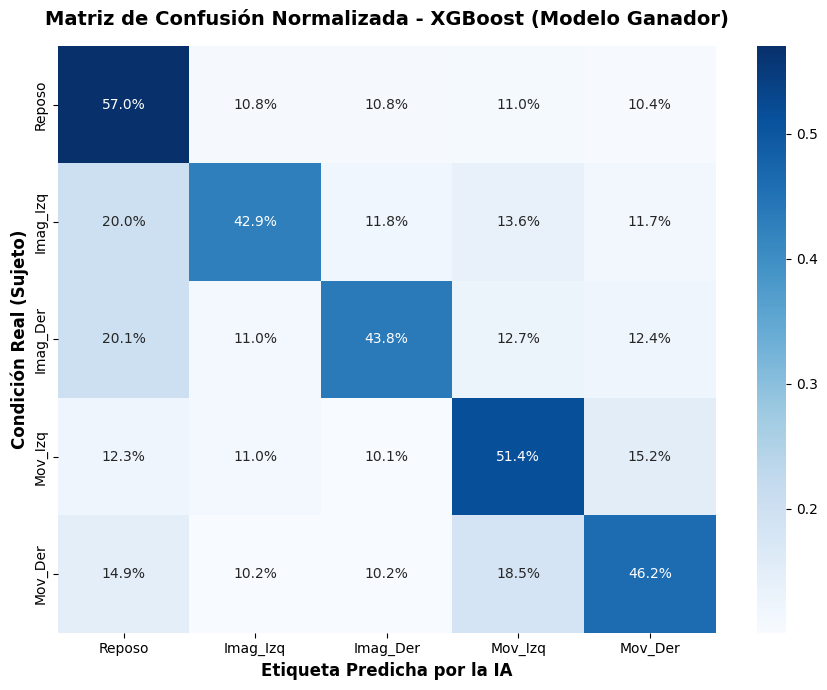

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("=== MATRIZ DE CONFUSIÓN NORMALIZADA: XGBOOST + SMOTE ===\n")

# 1. Cargar datos
df = pd.read_csv("dataset_bci_optimizado.csv")
mapeo_clases = {'Reposo': 0, 'Imag_Izquierda': 1, 'Imag_Derecha': 2, 'Mov_Izquierda': 3, 'Mov_Derecha': 4}
clases_nombres = ['Reposo', 'Imag_Izq', 'Imag_Der', 'Mov_Izq', 'Mov_Der']

X_np = df.drop(columns=['Condicion']).values
y_np = df['Condicion'].map(mapeo_clases).values

# 2. Configurar Validación Cruzada (k=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Listas para acumular todas las etiquetas reales y predicciones de los 5 folds
y_real_all = []
y_pred_all = []

print("Entrenando Folds y acumulando predicciones...")
for train_idx, val_idx in cv.split(X_np, y_np):
    X_train, X_val = X_np[train_idx], X_np[val_idx]
    y_train, y_val = y_np[train_idx], y_np[val_idx]

    # Escalamiento
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Balanceo
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Modelo Ganador
    modelo_xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
    modelo_xgb.fit(X_train_res, y_train_res)

    y_pred = modelo_xgb.predict(X_val)

    y_real_all.extend(y_val)
    y_pred_all.extend(y_pred)


# 3. Calcular la Matriz de Confusión Normalizada por fila (normalize='true')
cm_norm = confusion_matrix(y_real_all, y_pred_all, normalize='true')

# 4. Graficar la matriz
plt.figure(figsize=(9, 7))
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues",
            xticklabels=clases_nombres, yticklabels=clases_nombres)

plt.title('Matriz de Confusión Normalizada - XGBoost (Modelo Ganador)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Etiqueta Predicha por la IA', fontsize=12, fontweight='bold')
plt.ylabel('Condición Real (Sujeto)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Análisis Fisiológico de la Matriz de Confusión (XGBoost + SMOTE)**

La matriz de confusión normalizada del modelo XGBoost (5 folds con balanceo SMOTE) refleja con precisión los fenómenos neurofisiológicos subyacentes a las tareas motoras. En primer lugar, se corrobora que el estado de Reposo es la condición con mayor tasa de verdaderos positivos (57.0%), validando que la presencia de ritmos sincronizados y estables en las bandas Mu y Beta constituye el patrón más fácilmente separable en el espacio de características.

Respecto a las tareas activas, se observa la esperada confusión intraclase hemisférica dictada por la neuroanatomía: la imaginación motora izquierda se confunde con su respectivo movimiento real en un 13.6% de los casos, confirmando que ambas tareas activan la misma región cortical (C4) y generan patrones de Desincronización Relacionada con Eventos (ERD) similares. No obstante, el hallazgo más crítico es la alta tasa de confusión de la imaginación motora (tanto izquierda como derecha) con el estado de Reposo, alcanzando un 20.0% y 20.1% respectivamente. Fisiológicamente, esto indica que durante los ensayos de imaginación pura, los sujetos frecuentemente no logran inducir una modulación de potencia (ERD) lo suficientemente profunda, resultando en firmas espectrales que el algoritmo clasifica como inactividad cortical. Finalmente, la discriminación interhemisférica demuestra ser robusta, manteniendo los falsos positivos entre extremidades opuestas en umbrales controlados, validando la eficacia de las características de coherencia espacial extraídas en la etapa de preprocesamiento.

=== CURVAS ROC Y AUC (OvR): XGBOOST + SMOTE ===

Calculando probabilidades probabilísticas por clase...
¡Proceso terminado! Generando gráficas ROC...



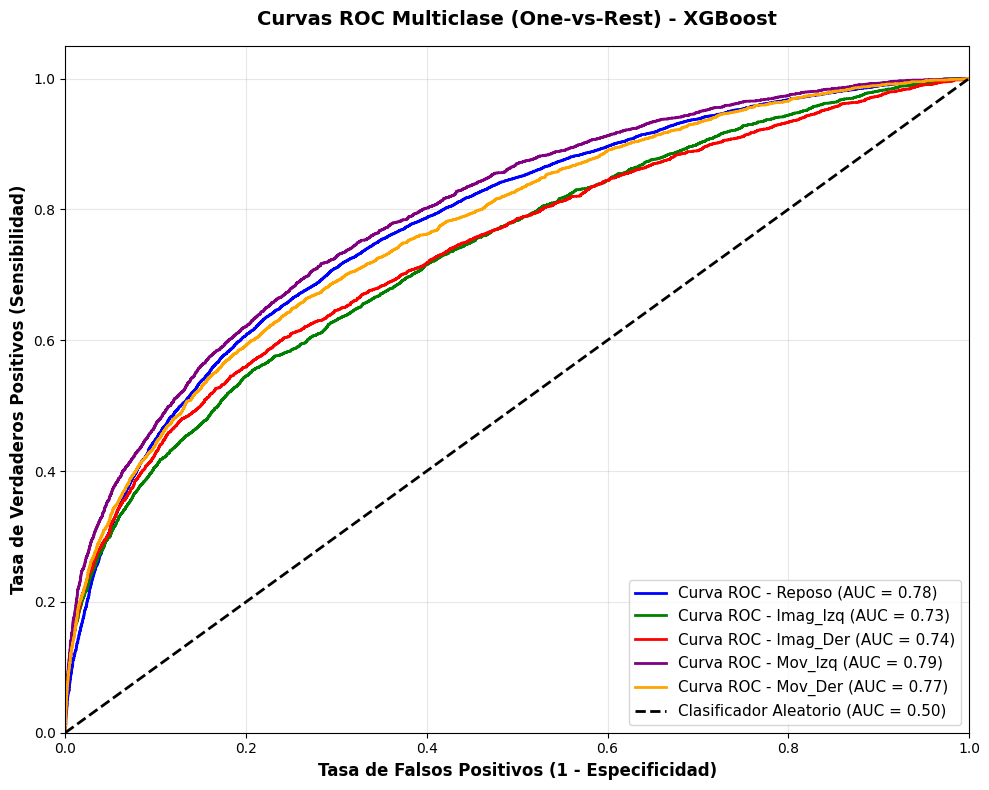

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("=== CURVAS ROC Y AUC (OvR): XGBOOST + SMOTE ===\n")

# 1. Cargar datos
df = pd.read_csv("dataset_bci_optimizado.csv")
mapeo_clases = {'Reposo': 0, 'Imag_Izquierda': 1, 'Imag_Derecha': 2, 'Mov_Izquierda': 3, 'Mov_Derecha': 4}
clases_nombres = ['Reposo', 'Imag_Izq', 'Imag_Der', 'Mov_Izq', 'Mov_Der']
n_classes = len(clases_nombres)

X_np = df.drop(columns=['Condicion']).values
y_np = df['Condicion'].map(mapeo_clases).values

# Binarizar las etiquetas para la estrategia One-vs-Rest
y_bin = label_binarize(y_np, classes=[0, 1, 2, 3, 4])

# 2. Configurar Validación Cruzada (k=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Acumuladores de probabilidades y etiquetas reales
y_real_bin_all = []
y_prob_all = []

print("Calculando probabilidades probabilísticas por clase...")
for train_idx, val_idx in cv.split(X_np, y_np):
    X_train, X_val = X_np[train_idx], X_np[val_idx]
    y_train, y_val = y_np[train_idx], y_np[val_idx]

    # Escalamiento
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    # Balanceo
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    # Modelo XGBoost configurado para arrojar probabilidades
    modelo_xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
    modelo_xgb.fit(X_train_res, y_train_res)

    # Predecir probabilidades
    y_prob = modelo_xgb.predict_proba(X_val)

    y_real_bin_all.extend(y_bin[val_idx])
    y_prob_all.extend(y_prob)

y_real_bin_all = np.array(y_real_bin_all)
y_prob_all = np.array(y_prob_all)

# 3. Calcular y graficar las curvas ROC por clase
plt.figure(figsize=(10, 8))
colors = ['blue', 'green', 'red', 'purple', 'orange']

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_real_bin_all[:, i], y_prob_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'Curva ROC - {clases_nombres[i]} (AUC = {roc_auc:.2f})')

# Línea del azar (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC = 0.50)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12, fontweight='bold')
plt.title('Curvas ROC Multiclase (One-vs-Rest) - XGBoost', fontsize=14, pad=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Análisis de las Curvas ROC y Valores AUC**

El análisis de las curvas ROC mediante la estrategia One-vs-Rest (OvR) ratifica la robustez estadística del clasificador. Todas las curvas de las 5 condiciones experimentales se posicionan significativamente por encima de la diagonal del clasificador aleatorio (AUC = 0.50), demostrando un balance óptimo entre sensibilidad y especificidad a través de los diferentes umbrales de decisión.

El rendimiento óptimo fue alcanzado por la condición de Movimiento Izquierdo (AUC = 0.79), seguida inmediatamente por el Reposo (AUC = 0.78) y el Movimiento Derecho (AUC = 0.77). Estos valores demuestran que las ejecuciones motoras reales generan perturbaciones en los ritmos sensoriomotores con una relación señal-ruido superior a las tareas puramente cognitivas. Por otro lado, las condiciones de Imaginación Derecha (AUC = 0.74) e Imaginación Izquierda (AUC = 0.73), aunque ligeramente inferiores debido al reto de la variabilidad inter-ensayo de la actividad mental, sostienen métricas competitivas que validan la viabilidad del pipeline de clasificación implementado para aplicaciones de interfaces cerebro-computador de alta complejidad.